In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Load Dataset
def load_data():
    # Simulated dataset
    data = {
        'tenure': np.random.randint(1, 72, 1000),
        'MonthlyCharges': np.random.uniform(20, 100, 1000),
        'TotalCharges': np.random.uniform(20, 7200, 1000),
        'Contract': np.random.choice(['Month-to-Month', 'One year', 'Two year'], 1000),
        'Churn': np.random.choice([0, 1], 1000)
    }
    df = pd.DataFrame(data)
    df = pd.get_dummies(df, columns=['Contract'], drop_first=True)
    return df

# Data Preprocessing
def preprocess_data(df):
    X = df.drop('Churn', axis=1)
    y = df['Churn']
    scaler = MinMaxScaler()
    X[['tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.fit_transform(
        X[['tenure', 'MonthlyCharges', 'TotalCharges']]
    )
    return train_test_split(X, y, test_size=0.2, random_state=42), scaler

# Build Model
def build_model(input_dim):
    model = Sequential([
        Dense(64, input_dim=input_dim, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Train Model
def train_model(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32, verbose=1)
    return model

# Evaluate Model
def evaluate_model(model, X_test, y_test):
    y_pred = (model.predict(X_test) > 0.5).astype(int)
    print("\nEvaluation Metrics:")
    print(classification_report(y_test, y_pred))
    print("Accuracy:", accuracy_score(y_test, y_pred))

# Real-Time Prediction with Limited Inputs
def predict_churn_simple(model, scaler):
    print("Enter customer details for prediction:")
    
    # Collect inputs
    tenure = float(input("Enter Tenure (in months): "))
    monthly_charges = float(input("Enter Monthly Charges ($): "))
    total_charges = tenure * monthly_charges  # Approximation if not provided
    contract_type = input("Enter Contract Type (Month-to-Month/One year/Two year): ")
    
    # Convert contract type to dummy variables
    contract_features = {
        'Month-to-Month': [1, 0],
        'One year': [0, 1],
        'Two year': [0, 0]
    }
    contract = contract_features.get(contract_type, [0, 0])  # Default to 'Two year' if invalid input
    
    # Prepare input data
    input_data = pd.DataFrame([{
        'tenure': tenure,
        'MonthlyCharges': monthly_charges,
        'TotalCharges': total_charges,
        'Contract_One year': contract[0],
        'Contract_Two year': contract[1]
    }])
    
    # Scale numeric features
    input_data[['tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.transform(
        input_data[['tenure', 'MonthlyCharges', 'TotalCharges']]
    )
    
    # Predict churn
    prediction_prob = model.predict(input_data).flatten()[0]
    prediction = "Yes" if prediction_prob > 0.5 else "No"
    print(f"\nPrediction: {prediction}")
    print(f"Churn Probability: {prediction_prob:.2f}")
    
    # Provide retention strategies if churn predicted
    if prediction == "Yes":
        print("\nRetention Strategies:")
        if tenure < 12:
            print("- Provide loyalty incentives (e.g., discounts, free upgrades) to increase tenure.")
        if monthly_charges > 70:
            print("- Offer a discount or bundle services to reduce monthly costs.")
        if contract_type == 'Month-to-Month':
            print("- Encourage switching to a longer-term contract with exclusive benefits.")

# Main Function
def main():
    df = load_data()
    (X_train, X_test, y_train, y_test), scaler = preprocess_data(df)
    
    # Build and train model
    model = build_model(X_train.shape[1])
    model = train_model(model, X_train, y_train, X_test, y_test)
    
    # Evaluate model
    evaluate_model(model, X_test, y_test)
    
    # Real-Time Prediction
    predict_churn_simple(model, scaler)

# Run the Program
if __name__ == '__main__':
    main()


C:\Users\dayaw\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.5079 - loss: 0.6941 - val_accuracy: 0.4850 - val_loss: 0.6953
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4953 - loss: 0.6939 - val_accuracy: 0.4800 - val_loss: 0.6986
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5372 - loss: 0.6900 - val_accuracy: 0.4900 - val_loss: 0.6970
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5200 - loss: 0.6918 - val_accuracy: 0.5150 - val_loss: 0.6946
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5311 - loss: 0.6931 - val_accuracy: 0.4900 - val_loss: 0.6992
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5111 - loss: 0.6893 - val_accuracy: 0.4750 - val_loss: 0.6957
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5433 - loss: 0.6902 - val_accuracy: 0.5050 - val_loss: 0.6977
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5201 - loss: 0.6895 - val_accuracy: 0.5050 - val_loss

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

def load_data(filepath=None):
    if filepath:
        df = pd.read_csv(filepath)
        df.drop('customerID', axis='columns', inplace=True)
    else:
        df = pd.DataFrame({
            'tenure': np.random.randint(1, 72, 1000),
            'MonthlyCharges': np.random.uniform(20, 100, 1000),
            'TotalCharges': np.random.uniform(20, 7200, 1000),
            'Contract': np.random.choice(['Month-to-Month', 'One year', 'Two year'], 1000),
            'Churn': np.random.choice([0, 1], 1000)
        })
    return df

def clean_data(df):
    df = df[df['TotalCharges'] != ' ']
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
    return df

def preprocess_data(df):
    df.replace({'No internet service': 'No', 'No phone service': 'No'}, inplace=True)
    
    yes_no_columns = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
                      'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                      'TechSupport', 'StreamingTV', 'StreamingMovies', 
                      'PaperlessBilling', 'Churn']
    for col in yes_no_columns:
        df[col] = df[col].replace({'Yes': 1, 'No': 0})
    
    df['gender'] = df['gender'].replace({'Female': 1, 'Male': 0})
    df = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod'], drop_first=True)
    return df

def scale_features(df, cols_to_scale):
    scaler = MinMaxScaler()
    df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
    return df, scaler

def plot_churn_distribution(df):
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x='Churn', palette='Set2')
    plt.title('Churn Distribution')
    plt.xlabel('Churn (1 = Yes, 0 = No)')
    plt.ylabel('Count')
    plt.show()

def plot_insights(df):
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2')
    plt.title('Monthly Charges vs Churn')
    plt.show()
    
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', palette='Set2')
    plt.title('Tenure Distribution by Churn')
    plt.show()

def build_model(input_shape):
    model = Sequential([
        Dense(64, input_shape=(input_shape,), activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

def train_model(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32, verbose=1)
    return model

def evaluate_model(model, X_test, y_test):
    y_pred_prob = model.predict(X_test).flatten()
    y_pred = (y_pred_prob > 0.5).astype(int)
    
    print("\nEvaluation Metrics:")
    print(classification_report(y_test, y_pred))
    print("Accuracy:", accuracy_score(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    plt.figure(figsize=(8, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_pred_prob):.2f}")
    plt.plot([0, 1], [0, 1], 'r--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-AUC Curve')
    plt.legend()
    plt.show()

def predict_churn_simple(model, scaler):
    print("Enter customer details for prediction:")
    tenure = float(input("Enter Tenure (in months): "))
    monthly_charges = float(input("Enter Monthly Charges ($): "))
    total_charges = tenure * monthly_charges  
    contract_type = input("Enter Contract Type (Month-to-Month/One year/Two year): ")
    
    contract_features = {'Month-to-Month': [1, 0], 'One year': [0, 1], 'Two year': [0, 0]}
    contract = contract_features.get(contract_type, [0, 0])
    
    input_data = pd.DataFrame([{
        'tenure': tenure,
        'MonthlyCharges': monthly_charges,
        'TotalCharges': total_charges,
        'Contract_One year': contract[0],
        'Contract_Two year': contract[1]
    }])
    
    input_data[['tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.transform(
        input_data[['tenure', 'MonthlyCharges', 'TotalCharges']]
    )
    
    prediction_prob = model.predict(input_data).flatten()[0]
    prediction = "Yes" if prediction_prob > 0.5 else "No"
    print(f"\nPrediction: {prediction}")
    print(f"Churn Probability: {prediction_prob:.2f}")
    
    if prediction == "Yes":
        print("\nRetention Strategies:")
        print("- Offer a loyalty discount or free upgrade.")
        print("- Provide personalized customer service.")
        print("- Analyze customer behavior to address specific pain points.")

def main():
    df = load_data()
    df = clean_data(df)
    df = preprocess_data(df)
    df, scaler = scale_features(df, ['tenure', 'MonthlyCharges', 'TotalCharges'])
    X, y = df.drop('Churn', axis=1), df['Churn']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    plot_churn_distribution(df)
    plot_insights(df)
    
    model = build_model(X_train.shape[1])
    model = train_model(model, X_train, y_train, X_test, y_test)
    evaluate_model(model, X_test, y_test)
    predict_churn_simple(model, scaler)

if __name__ == '__main__':
    main()


KeyError: 'Partner'

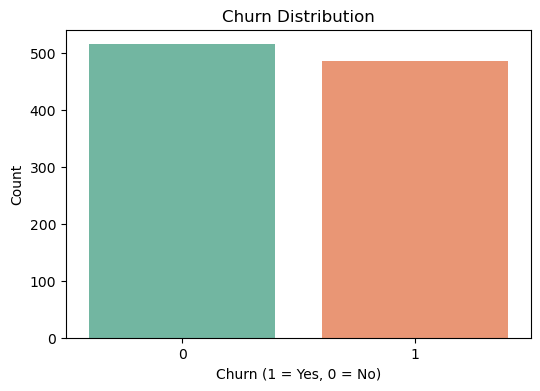

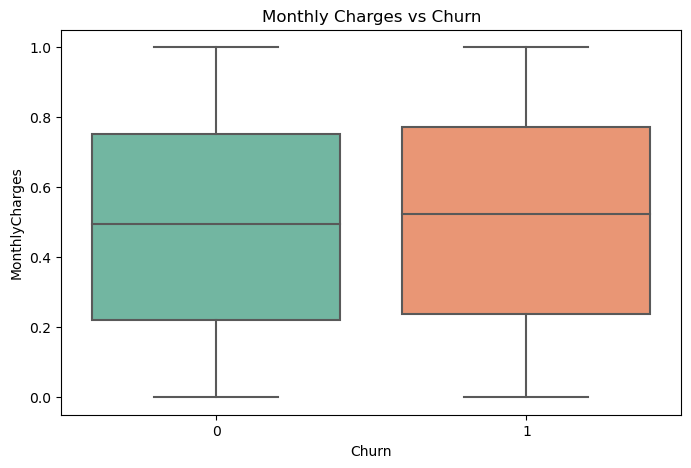

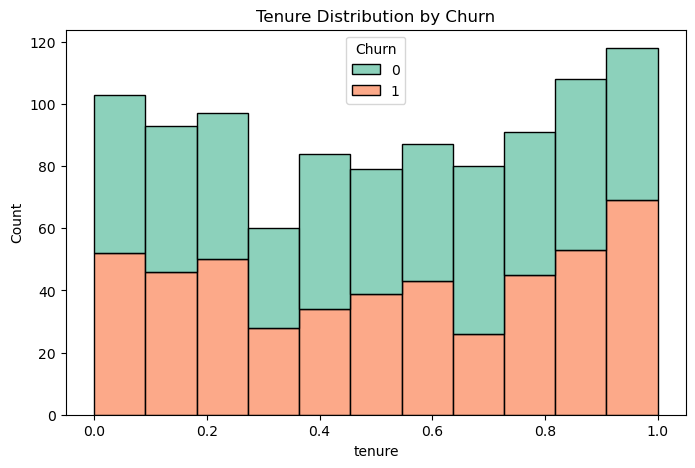

C:\Users\dayaw\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5136 - loss: 0.6942 - val_accuracy: 0.4700 - val_loss: 0.6978
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5309 - loss: 0.6873 - val_accuracy: 0.4500 - val_loss: 0.6996
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5439 - loss: 0.6895 - val_accuracy: 0.4800 - val_loss: 0.6961
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5110 - loss: 0.6906 - val_accuracy: 0.4750 - val_loss: 0.6977
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5454 - loss: 0.6886 - val_accuracy: 0.4900 - val_loss: 0.6969
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5338 - loss: 0.6858 - val_accuracy: 0.4750 - val_loss: 0.6982
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5382 - loss: 0.6884 - val_accuracy: 0.5100 - val_loss: 0.6964
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5437 - loss: 0.6885 - val_accuracy: 0.5050 - val_loss

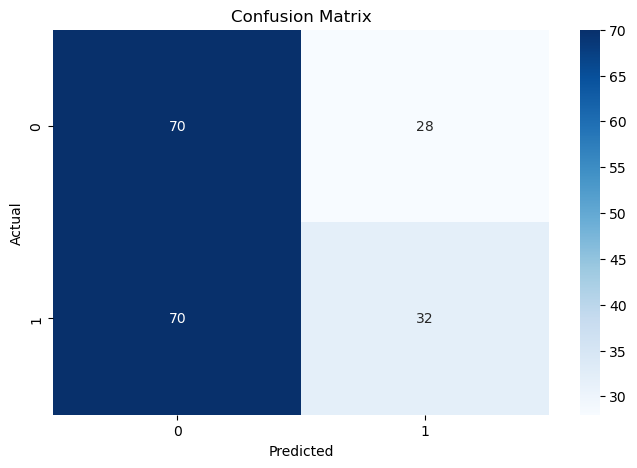

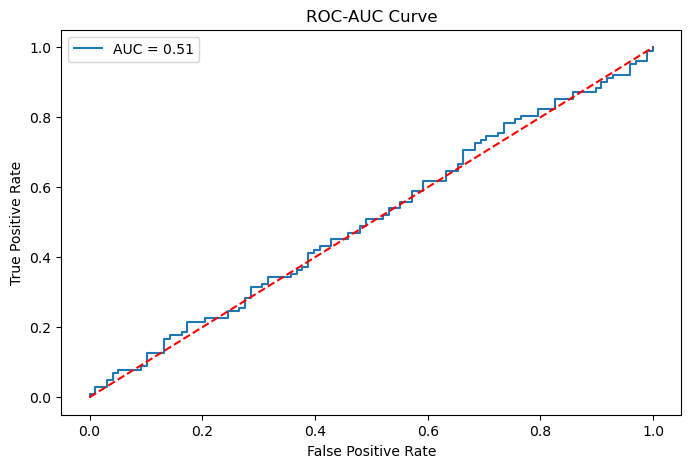

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

def load_data(filepath=None):
    if filepath:
        df = pd.read_csv(filepath)
        df.columns = df.columns.str.strip()  # Remove any leading/trailing spaces from column names
        df.drop('customerID', axis='columns', inplace=True)
    else:
        df = pd.DataFrame({
            'tenure': np.random.randint(1, 72, 1000),
            'MonthlyCharges': np.random.uniform(20, 100, 1000),
            'TotalCharges': np.random.uniform(20, 7200, 1000),
            'Contract': np.random.choice(['Month-to-Month', 'One year', 'Two year'], 1000),
            'Churn': np.random.choice([0, 1], 1000)
        })
    return df

def clean_data(df):
    df = df[df['TotalCharges'] != ' ']
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
    return df

def preprocess_data(df):
    df.replace({'No internet service': 'No', 'No phone service': 'No'}, inplace=True)
    
    yes_no_columns = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
                      'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                      'TechSupport', 'StreamingTV', 'StreamingMovies', 
                      'PaperlessBilling', 'Churn']
    
    missing_cols = [col for col in yes_no_columns if col not in df.columns]
    if missing_cols:
        print(f"Warning: Missing columns in dataset - {missing_cols}")
    
    for col in yes_no_columns:
        if col in df.columns:
            df[col] = df[col].replace({'Yes': 1, 'No': 0})
    
    if 'gender' in df.columns:
        df['gender'] = df['gender'].replace({'Female': 1, 'Male': 0})
    
    categorical_columns = ['InternetService', 'Contract', 'PaymentMethod']
    df = pd.get_dummies(df, columns=[col for col in categorical_columns if col in df.columns], drop_first=True)
    
    return df

def scale_features(df, cols_to_scale):
    scaler = MinMaxScaler()
    df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
    return df, scaler

def plot_churn_distribution(df):
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x='Churn', palette='Set2')
    plt.title('Churn Distribution')
    plt.xlabel('Churn (1 = Yes, 0 = No)')
    plt.ylabel('Count')
    plt.show()

def plot_insights(df):
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2')
    plt.title('Monthly Charges vs Churn')
    plt.show()
    
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', palette='Set2')
    plt.title('Tenure Distribution by Churn')
    plt.show()

def build_model(input_shape):
    model = Sequential([
        Dense(64, input_shape=(input_shape,), activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

def train_model(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32, verbose=1)
    return model

def evaluate_model(model, X_test, y_test):
    y_pred_prob = model.predict(X_test).flatten()
    y_pred = (y_pred_prob > 0.5).astype(int)
    
    print("\nEvaluation Metrics:")
    print(classification_report(y_test, y_pred))
    print("Accuracy:", accuracy_score(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    plt.figure(figsize=(8, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_pred_prob):.2f}")
    plt.plot([0, 1], [0, 1], 'r--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-AUC Curve')
    plt.legend()
    plt.show()

def main():
    df = load_data()
    df = clean_data(df)
    df = preprocess_data(df)
    df, scaler = scale_features(df, ['tenure', 'MonthlyCharges', 'TotalCharges'])
    X, y = df.drop('Churn', axis=1), df['Churn']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    plot_churn_distribution(df)
    plot_insights(df)
    
    model = build_model(X_train.shape[1])
    model = train_model(model, X_train, y_train, X_test, y_test)
    evaluate_model(model, X_test, y_test)

if __name__ == '__main__':
    main()


Epoch 1/10


C:\Users\dayaw\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4914 - loss: 0.6938 - val_accuracy: 0.4800 - val_loss: 0.6948
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5186 - loss: 0.6917 - val_accuracy: 0.4850 - val_loss: 0.6954
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5283 - loss: 0.6908 - val_accuracy: 0.4850 - val_loss: 0.6957
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5274 - loss: 0.6907 - val_accuracy: 0.4800 - val_loss: 0.6961
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5008 - loss: 0.6935 - val_accuracy: 0.4550 - val_loss: 0.6953
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5614 - loss: 0.6892 - val_accuracy: 0.4450 - val_loss: 0.6967
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5207 - loss: 0.6906 - val_accuracy: 0.4700 - val_loss: 0.6976
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5319 - loss: 0.6914 - val_accuracy: 0.4550 - val_loss: 0.6967
Ep

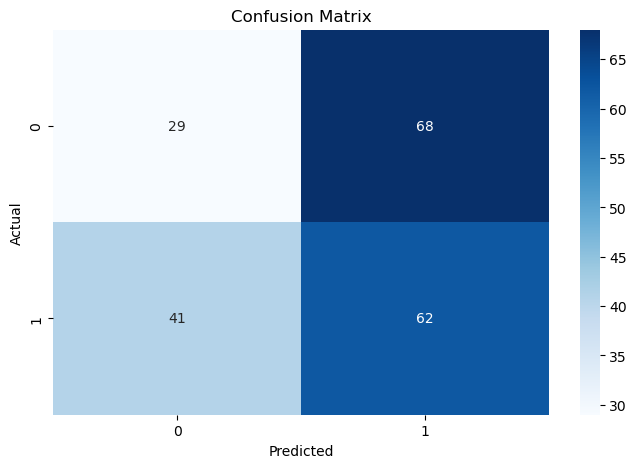

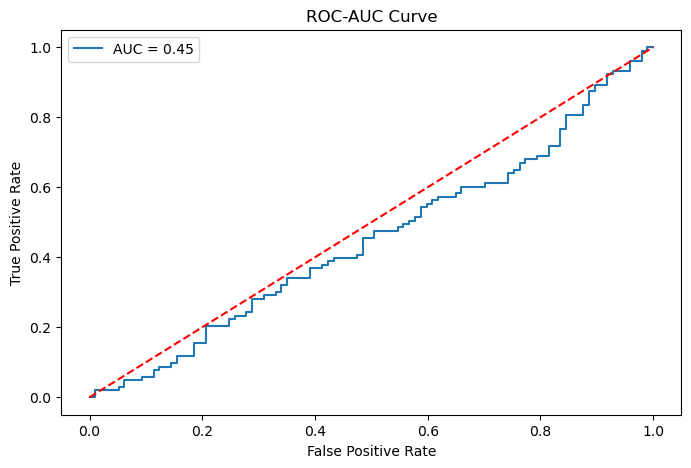

Enter customer details for prediction:
Enter Tenure (in months): 10
Enter Monthly Charges ($): 25
Enter Contract Type (Month-to-Month/One year/Two year): One year
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

Prediction: No
Churn Probability: 0.47


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

def load_data(filepath=None):
    if filepath:
        df = pd.read_csv(filepath)
        df.columns = df.columns.str.strip()
        df.drop('customerID', axis='columns', inplace=True)
    else:
        df = pd.DataFrame({
            'tenure': np.random.randint(1, 72, 1000),
            'MonthlyCharges': np.random.uniform(20, 100, 1000),
            'TotalCharges': np.random.uniform(20, 7200, 1000),
            'Contract': np.random.choice(['Month-to-Month', 'One year', 'Two year'], 1000),
            'Churn': np.random.choice([0, 1], 1000)
        })
    return df

def clean_data(df):
    df = df[df['TotalCharges'] != ' ']
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
    return df

def preprocess_data(df):
    df.replace({'No internet service': 'No', 'No phone service': 'No'}, inplace=True)
    yes_no_columns = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
                      'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                      'TechSupport', 'StreamingTV', 'StreamingMovies', 
                      'PaperlessBilling', 'Churn']
    missing_cols = [col for col in yes_no_columns if col not in df.columns]
    if missing_cols:
        print(f"Warning: Missing columns in dataset - {missing_cols}")
    for col in yes_no_columns:
        if col in df.columns:
            df[col] = df[col].replace({'Yes': 1, 'No': 0})
    if 'gender' in df.columns:
        df['gender'] = df['gender'].replace({'Female': 1, 'Male': 0})
    categorical_columns = ['InternetService', 'Contract', 'PaymentMethod']
    df = pd.get_dummies(df, columns=[col for col in categorical_columns if col in df.columns], drop_first=True)
    return df

def scale_features(df, cols_to_scale):
    scaler = MinMaxScaler()
    df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
    return df, scaler

def build_model(input_shape):
    model = Sequential([
        Dense(64, input_shape=(input_shape,), activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

def train_model(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32, verbose=1)
    return model

def evaluate_model(model, X_test, y_test):
    y_pred_prob = model.predict(X_test).flatten()
    y_pred = (y_pred_prob > 0.5).astype(int)
    print("\nEvaluation Metrics:")
    print(classification_report(y_test, y_pred))
    print("Accuracy:", accuracy_score(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    plt.figure(figsize=(8, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_pred_prob):.2f}")
    plt.plot([0, 1], [0, 1], 'r--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-AUC Curve')
    plt.legend()
    plt.show()

def predict_churn_simple(model, scaler):
    print("Enter customer details for prediction:")
    tenure = float(input("Enter Tenure (in months): "))
    monthly_charges = float(input("Enter Monthly Charges ($): "))
    total_charges = tenure * monthly_charges
    contract_type = input("Enter Contract Type (Month-to-Month/One year/Two year): ")
    contract_features = {'Month-to-Month': [1, 0], 'One year': [0, 1], 'Two year': [0, 0]}
    contract = contract_features.get(contract_type, [0, 0])
    input_data = pd.DataFrame([{
        'tenure': tenure,
        'MonthlyCharges': monthly_charges,
        'TotalCharges': total_charges,
        'Contract_One year': contract[0],
        'Contract_Two year': contract[1]
    }])
    input_data[['tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.transform(
        input_data[['tenure', 'MonthlyCharges', 'TotalCharges']]
    )
    prediction_prob = model.predict(input_data).flatten()[0]
    prediction = "Yes" if prediction_prob > 0.5 else "No"
    print(f"\nPrediction: {prediction}")
    print(f"Churn Probability: {prediction_prob:.2f}")
    if prediction == "Yes":
        print("\nRetention Strategies:")
        print("- Offer a loyalty discount or free upgrade.")
        print("- Provide personalized customer service.")
        print("- Analyze customer behavior to address specific pain points.")

def main():
    df = load_data()
    df = clean_data(df)
    df = preprocess_data(df)
    df, scaler = scale_features(df, ['tenure', 'MonthlyCharges', 'TotalCharges'])
    X, y = df.drop('Churn', axis=1), df['Churn']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = build_model(X_train.shape[1])
    model = train_model(model, X_train, y_train, X_test, y_test)
    evaluate_model(model, X_test, y_test)
    predict_churn_simple(model, scaler)

if __name__ == '__main__':
    main()


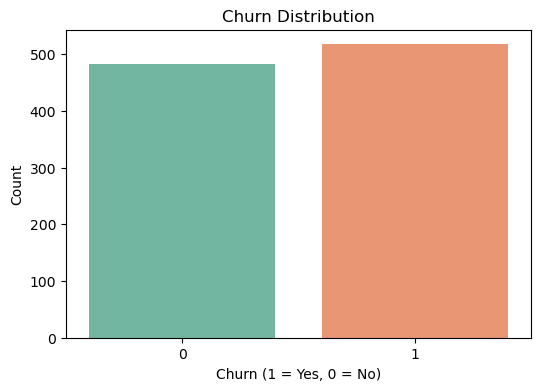

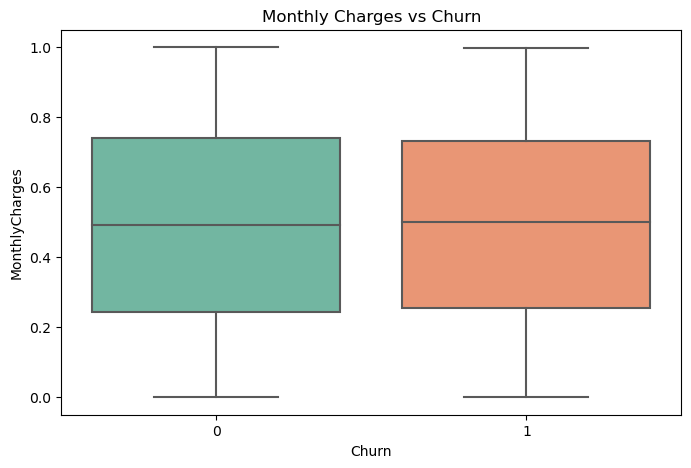

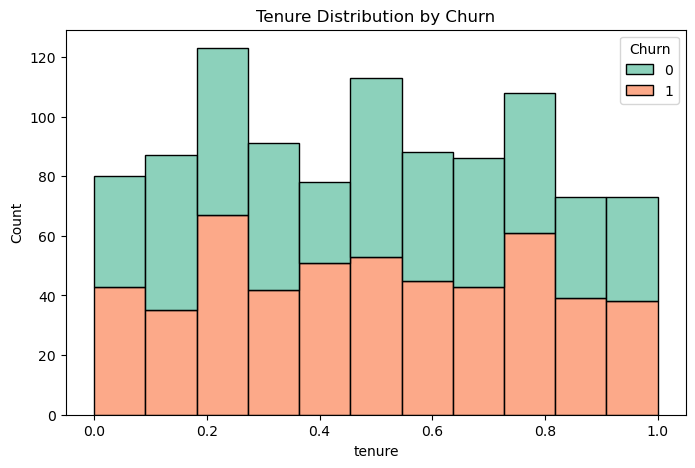

Epoch 1/10


C:\Users\dayaw\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5206 - loss: 0.6954 - val_accuracy: 0.5450 - val_loss: 0.6879
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4891 - loss: 0.6941 - val_accuracy: 0.5200 - val_loss: 0.6912
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5012 - loss: 0.6890 - val_accuracy: 0.5150 - val_loss: 0.6917
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5034 - loss: 0.6887 - val_accuracy: 0.4550 - val_loss: 0.6940
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5651 - loss: 0.6880 - val_accuracy: 0.4600 - val_loss: 0.6927
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5150 - loss: 0.6912 - val_accuracy: 0.4600 - val_loss: 0.6918
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5314 - loss: 0.6879 - val_accuracy: 0.4700 - val_loss: 0.6918
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5420 - loss: 0.6907 - val_accuracy: 0.4900 - val_loss: 0.6935
Epo

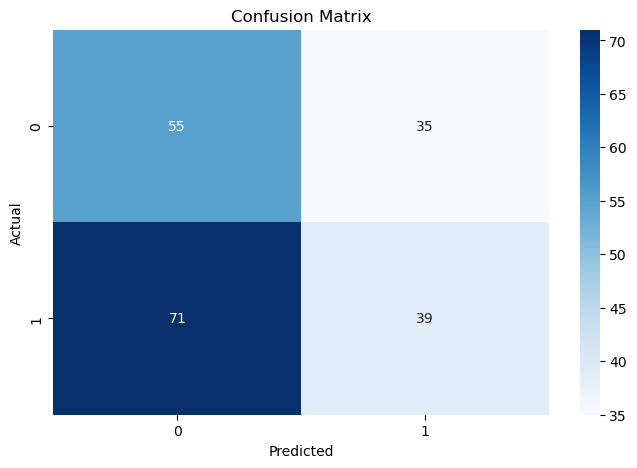

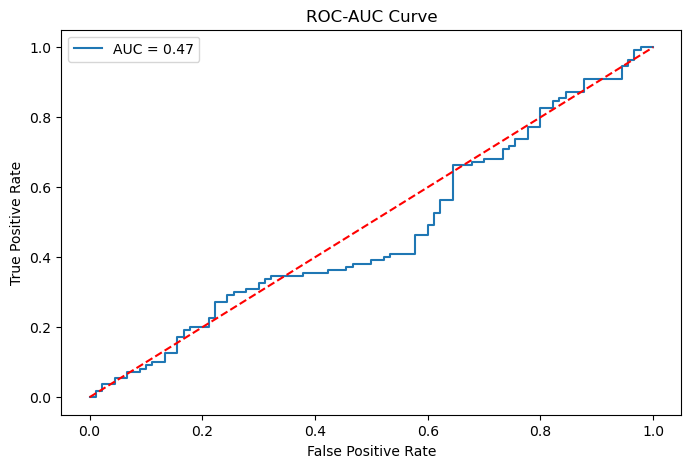

Enter customer details for prediction:


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

def load_data(filepath=None):
    if filepath:
        df = pd.read_csv("customer_churn.csv")
        df.columns = df.columns.str.strip()  # Remove any leading/trailing spaces from column names
        df.drop('customerID', axis='columns', inplace=True)
    else:
        df = pd.DataFrame({
            'tenure': np.random.randint(1, 72, 1000),
            'MonthlyCharges': np.random.uniform(20, 100, 1000),
            'TotalCharges': np.random.uniform(20, 7200, 1000),
            'Contract': np.random.choice(['Month-to-Month', 'One year', 'Two year'], 1000),
            'Churn': np.random.choice([0, 1], 1000)
        })
    return df

def clean_data(df):
    df = df[df['TotalCharges'] != ' ']
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
    return df

def preprocess_data(df):
    df.replace({'No internet service': 'No', 'No phone service': 'No'}, inplace=True)
    
    yes_no_columns = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
                      'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                      'TechSupport', 'StreamingTV', 'StreamingMovies', 
                      'PaperlessBilling', 'Churn']
    
    missing_cols = [col for col in yes_no_columns if col not in df.columns]
    if missing_cols:
        print(f"Warning: Missing columns in dataset - {missing_cols}")
    
    for col in yes_no_columns:
        if col in df.columns:
            df[col] = df[col].replace({'Yes': 1, 'No': 0})
    
    if 'gender' in df.columns:
        df['gender'] = df['gender'].replace({'Female': 1, 'Male': 0})
    
    categorical_columns = ['InternetService', 'Contract', 'PaymentMethod']
    df = pd.get_dummies(df, columns=[col for col in categorical_columns if col in df.columns], drop_first=True)
    
    return df

def scale_features(df, cols_to_scale):
    scaler = MinMaxScaler()
    df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
    return df, scaler

def build_model(input_shape):
    model = Sequential([
        Dense(64, input_shape=(input_shape,), activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model


def train_model(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32, verbose=1)
    return model

def evaluate_model(model, X_test, y_test):
    y_pred_prob = model.predict(X_test).flatten()
    y_pred = (y_pred_prob > 0.5).astype(int)
    print("\nEvaluation Metrics:")
    print(classification_report(y_test, y_pred))
    print("Accuracy:", accuracy_score(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    plt.figure(figsize=(8, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_pred_prob):.2f}")
    plt.plot([0, 1], [0, 1], 'r--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-AUC Curve')
    plt.legend()
    plt.show()
    
    
def plot_churn_distribution(df):
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x='Churn', palette='Set2')
    plt.title('Churn Distribution')
    plt.xlabel('Churn (1 = Yes, 0 = No)')
    plt.ylabel('Count')
    plt.show()

def plot_insights(df):
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2')
    plt.title('Monthly Charges vs Churn')
    plt.show()
    
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', palette='Set2')
    plt.title('Tenure Distribution by Churn')
    plt.show()

def predict_churn_simple(model, scaler):
    print("Enter customer details for prediction:")
    tenure = float(input("Enter Tenure (in months): "))
    monthly_charges = float(input("Enter Monthly Charges ($): "))
    total_charges = tenure * monthly_charges  
    contract_type = input("Enter Contract Type (Month-to-Month/One year/Two year): ")
    
    contract_features = {'Month-to-Month': [1, 0], 'One year': [0, 1], 'Two year': [0, 0]}
    contract = contract_features.get(contract_type, [0, 0])
    
    input_data = pd.DataFrame([{
        'tenure': tenure,
        'MonthlyCharges': monthly_charges,
        'TotalCharges': total_charges,
        'Contract_One year': contract[0],
        'Contract_Two year': contract[1]
    }])
    
    input_data[['tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.transform(
        input_data[['tenure', 'MonthlyCharges', 'TotalCharges']]
    )
    
    prediction_prob = model.predict(input_data).flatten()[0]
    prediction = "Yes" if prediction_prob > 0.5 else "No"
    print(f"\nPrediction: {prediction}")
    print(f"Churn Probability: {prediction_prob:.2f}")
    
    if prediction == "Yes":
        print("\nRetention Strategies:")
        print("- Offer a loyalty discount or free upgrade.")
        print("- Provide personalized customer service.")
        print("- Analyze customer behavior to address specific pain points.")

def main():
    df = load_data()
    df = clean_data(df)
    df = preprocess_data(df)
    df, scaler = scale_features(df, ['tenure', 'MonthlyCharges', 'TotalCharges'])
    X, y = df.drop('Churn', axis=1), df['Churn']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    plot_churn_distribution(df)
    plot_insights(df)
    
    model = build_model(X_train.shape[1])
    model = train_model(model, X_train, y_train, X_test, y_test)
    evaluate_model(model, X_test, y_test)
    predict_churn_simple(model, scaler)

if __name__ == '__main__':
    main()


In [9]:
model.save('major.keras')

NameError: name 'model' is not defined

In [2]:
!pip install streamlit


  Obtaining dependency information for streamlit from https://files.pythonhosted.org/packages/46/9e/e51e34f504940da00145795b9e8be9c129704708b071f672f3626a37d842/streamlit-1.44.0-py3-none-any.whl.metadata
  Using cached streamlit-1.44.0-py3-none-any.whl.metadata (8.9 kB)
  Obtaining dependency information for altair<6,>=4.0 from https://files.pythonhosted.org/packages/aa/f3/0b6ced594e51cc95d8c1fc1640d3623770d01e4969d29c0bd09945fafefa/altair-5.5.0-py3-none-any.whl.metadata
  Obtaining dependency information for blinker<2,>=1.0.0 from https://files.pythonhosted.org/packages/10/cb/f2ad4230dc2eb1a74edf38f1a38b9b52277f75bef262d8908e60d957e13c/blinker-1.9.0-py3-none-any.whl.metadata
  Obtaining dependency information for cachetools<6,>=4.0 from https://files.pythonhosted.org/packages/72/76/20fa66124dbe6be5cafeb312ece67de6b61dd91a0247d1ea13db4ebb33c2/cachetools-5.5.2-py3-none-any.whl.metadata
  Obtaining dependency information for gitpython!=3.1.19,<4,>=3.0.7 from https://files.pythonhosted.or

In [3]:
streamlit run app.py


SyntaxError: invalid syntax (507122745.py, line 1)

SyntaxError: invalid syntax (3096922081.py, line 15)

C:\Users\dayaw\AppData\Local\Temp\ipykernel_32964\895704203.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])


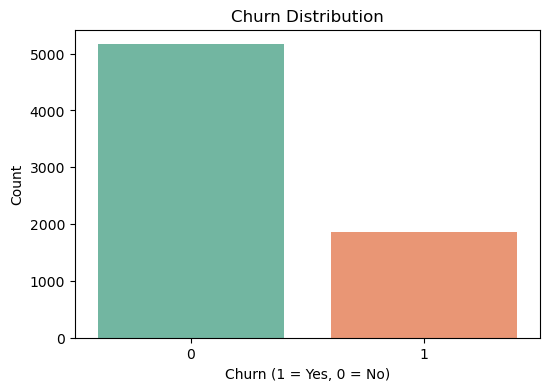

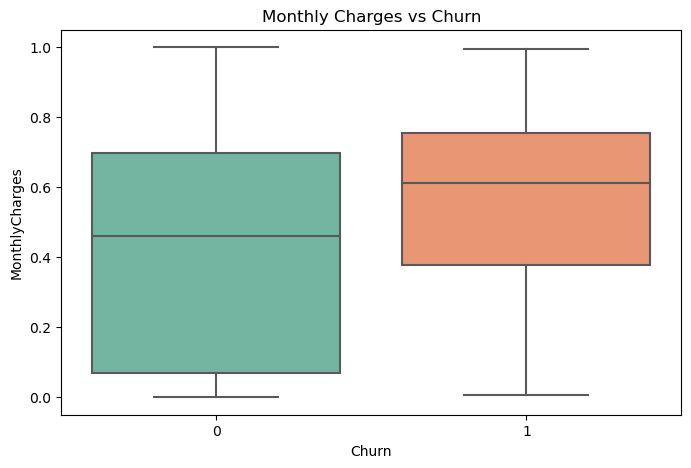

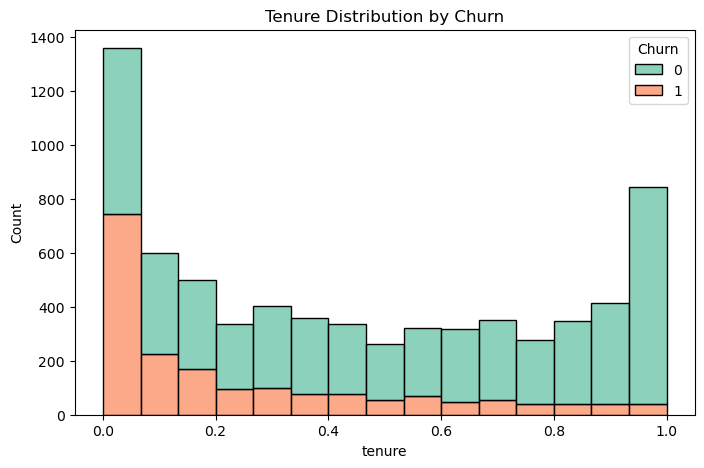

Epoch 1/10


C:\Users\dayaw\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6525 - loss: 0.5818 - val_accuracy: 0.7775 - val_loss: 0.4428
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7955 - loss: 0.4268 - val_accuracy: 0.7783 - val_loss: 0.4404
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8107 - loss: 0.4054 - val_accuracy: 0.7939 - val_loss: 0.4357
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8069 - loss: 0.4106 - val_accuracy: 0.7846 - val_loss: 0.4383
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8098 - loss: 0.4090 - val_accuracy: 0.7946 - val_loss: 0.4356
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8102 - loss: 0.4063 - val_accuracy: 0.7896 - val_loss: 0.4389
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8008 - loss: 0.4160 - val_accuracy: 0.7946 - val_loss: 0.4363
Epoch 8/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8048 - loss: 0.4063 - val_accuracy: 0.7960 - val_

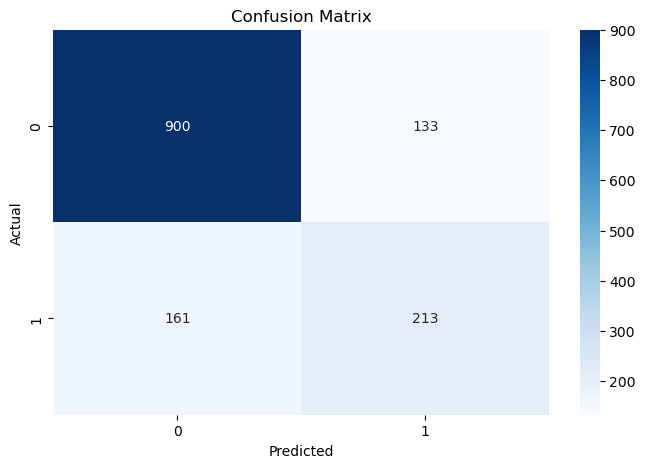

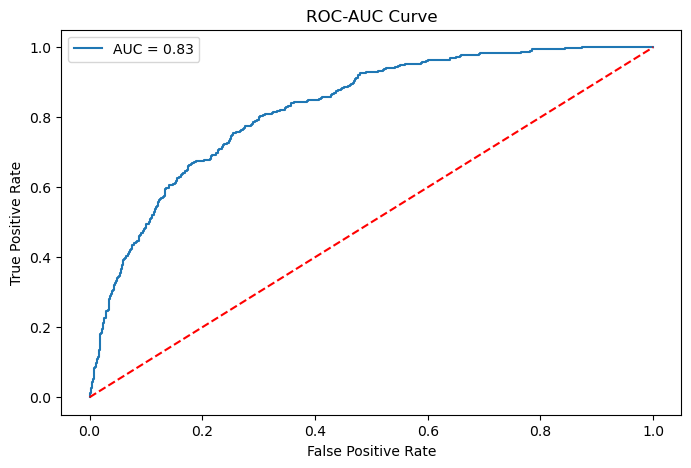

Enter customer details for prediction:
Enter Tenure (in months): 2
Enter Monthly Charges ($): 50
Enter Contract Type (Month-to-Month/One year/Two year): Two year


InvalidArgumentError: Graph execution error:

Detected at node sequential_1/dense_1/Relu defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "C:\Users\dayaw\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>

  File "C:\Users\dayaw\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance

  File "C:\Users\dayaw\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 736, in start

  File "C:\Users\dayaw\anaconda3\Lib\site-packages\tornado\platform\asyncio.py", line 195, in start

  File "C:\Users\dayaw\anaconda3\Lib\asyncio\base_events.py", line 607, in run_forever

  File "C:\Users\dayaw\anaconda3\Lib\asyncio\base_events.py", line 1922, in _run_once

  File "C:\Users\dayaw\anaconda3\Lib\asyncio\events.py", line 80, in _run

  File "C:\Users\dayaw\anaconda3\Lib\site-packages\ipykernel\kernelbase.py", line 516, in dispatch_queue

  F

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

def load_data(filepath="customer_churn.csv"):
    df = pd.read_csv(filepath)  # Load the dataset using the correct filename
    df.columns = df.columns.str.strip()  # Remove any leading/trailing spaces from column names
    df.drop('customerID', axis='columns', inplace=True, errors='ignore')  # Drop if it exists
    return df

def clean_data(df):
    df = df[df['TotalCharges'] != ' ']
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
    return df
12

def preprocess_data(df):
    df.replace({'No internet service': 'No', 'No phone service': 'No'}, inplace=True)
    
    yes_no_columns = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
                      'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                      'TechSupport', 'StreamingTV', 'StreamingMovies', 
                      'PaperlessBilling', 'Churn']
    
    missing_cols = [col for col in yes_no_columns if col not in df.columns]
    if missing_cols:
        print(f"Warning: Missing columns in dataset - {missing_cols}")
    
    for col in yes_no_columns:
        if col in df.columns:
            df[col] = df[col].replace({'Yes': 1, 'No': 0})
    
    if 'gender' in df.columns:
        df['gender'] = df['gender'].replace({'Female': 1, 'Male': 0})
    
    categorical_columns = ['InternetService', 'Contract', 'PaymentMethod']
    df = pd.get_dummies(df, columns=[col for col in categorical_columns if col in df.columns], drop_first=True)
    
    return df

def scale_features(df, cols_to_scale):
    scaler = MinMaxScaler()
    df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
    return df, scaler

def build_model(input_shape):
    model = Sequential([
        Dense(64, input_shape=(input_shape,), activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model


def train_model(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32, verbose=1)
    return model

def evaluate_model(model, X_test, y_test):
    y_pred_prob = model.predict(X_test).flatten()
    y_pred = (y_pred_prob > 0.5).astype(int)
    print("\nEvaluation Metrics:")
    print(classification_report(y_test, y_pred))
    print("Accuracy:", accuracy_score(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    plt.figure(figsize=(8, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_pred_prob):.2f}")
    plt.plot([0, 1], [0, 1], 'r--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-AUC Curve')
    plt.legend()
    plt.show()
    
    
def plot_churn_distribution(df):
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x='Churn', palette='Set2')
    plt.title('Churn Distribution')
    plt.xlabel('Churn (1 = Yes, 0 = No)')
    plt.ylabel('Count')
    plt.show()

def plot_insights(df):
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2')
    plt.title('Monthly Charges vs Churn')
    plt.show()
    
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', palette='Set2')
    plt.title('Tenure Distribution by Churn')
    plt.show()

def predict_churn_simple(model, scaler):
    print("Enter customer details for prediction:")
    tenure = float(input("Enter Tenure (in months): "))
    monthly_charges = float(input("Enter Monthly Charges ($): "))
    total_charges = tenure * monthly_charges  
    contract_type = input("Enter Contract Type (Month-to-Month/One year/Two year): ")
    
    contract_features = {'Month-to-Month': [1, 0], 'One year': [0, 1], 'Two year': [0, 0]}
    contract = contract_features.get(contract_type, [0, 0])
    
    input_data = pd.DataFrame([{
        'tenure': tenure,
        'MonthlyCharges': monthly_charges,
        'TotalCharges': total_charges,
        'Contract_One year': contract[0],
        'Contract_Two year': contract[1]
    }])
    
    input_data[['tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.transform(
        input_data[['tenure', 'MonthlyCharges', 'TotalCharges']]
    )
    
    prediction_prob = model.predict(input_data).flatten()[0]
    prediction = "Yes" if prediction_prob > 0.5 else "No"
    print(f"\nPrediction: {prediction}")
    print(f"Churn Probability: {prediction_prob:.2f}")
    
    if prediction == "Yes":
        print("\nRetention Strategies:")
        print("- Offer a loyalty discount or free upgrade.")
        print("- Provide personalized customer service.")
        print("- Analyze customer behavior to address specific pain points.")

def main():
    df = load_data()
    df = clean_data(df)
    df = preprocess_data(df)
    df, scaler = scale_features(df, ['tenure', 'MonthlyCharges', 'TotalCharges'])
    X, y = df.drop('Churn', axis=1), df['Churn']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    plot_churn_distribution(df)
    plot_insights(df)
    
    model = build_model(X_train.shape[1])
    model = train_model(model, X_train, y_train, X_test, y_test)
    evaluate_model(model, X_test, y_test)
    predict_churn_simple(model, scaler)

if __name__ == '__main__':
    main()


C:\Users\dayaw\AppData\Local\Temp\ipykernel_14288\3442946426.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])


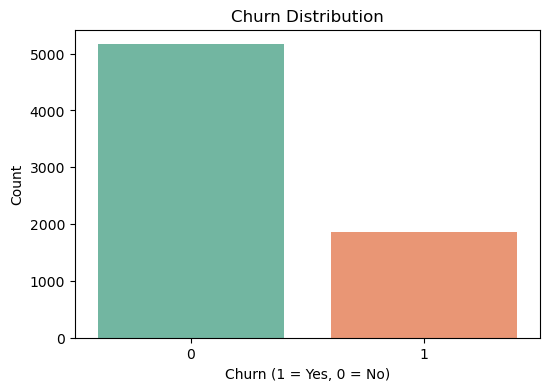

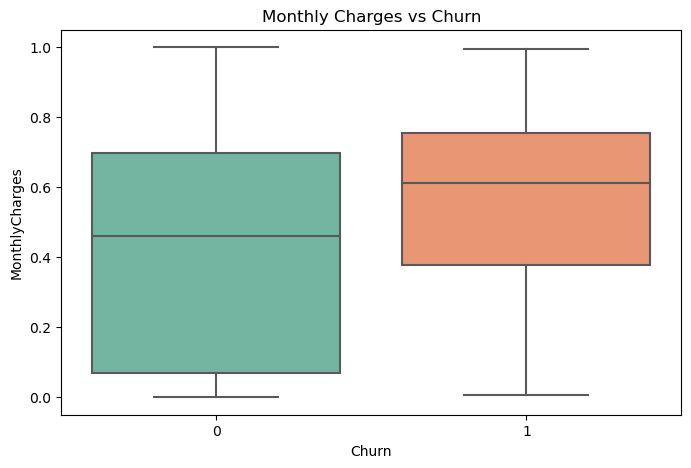

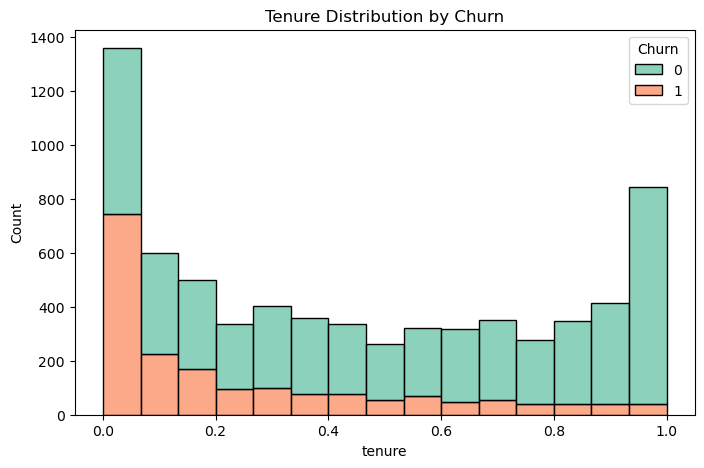

C:\Users\dayaw\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6917 - loss: 0.5523 - val_accuracy: 0.7790 - val_loss: 0.4438
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8032 - loss: 0.4117 - val_accuracy: 0.7854 - val_loss: 0.4376
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8004 - loss: 0.4165 - val_accuracy: 0.7839 - val_loss: 0.4378
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8055 - loss: 0.4128 - val_accuracy: 0.7846 - val_loss: 0.4348
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8029 - loss: 0.4177 - val_accuracy: 0.7861 - val_loss: 0.4368
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8055 - loss: 0.4113 - val_accuracy: 0.7811 - val_loss: 0.4359
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8003 - loss: 0.4091 - val_accuracy: 0.7839 - val_loss: 0.4414
Epoch 8/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8113 - loss: 0.3922 - val_accuracy: 0.

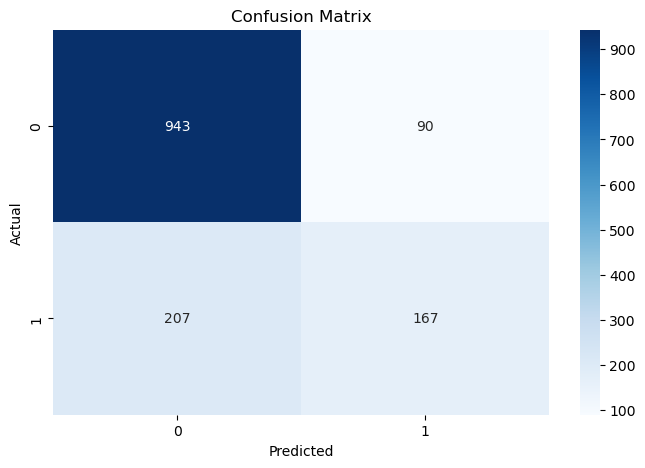

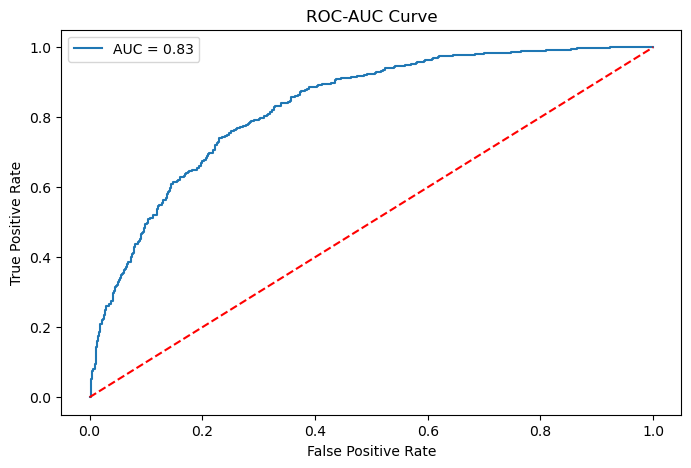

Enter customer details for prediction:
Enter Tenure (in months): 12
Enter Monthly Charges ($): 85
Enter Contract Type (Month-to-Month/One year/Two year): Two year
Internet Service (DSL/Fiber optic/No): No
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step

Prediction: No
Churn Probability: 0.04


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

def load_data(filepath="customer_churn.csv"):
    df = pd.read_csv(filepath)  # Load the dataset using the correct filename
    df.columns = df.columns.str.strip()  # Remove any leading/trailing spaces from column names
    df.drop('customerID', axis='columns', inplace=True, errors='ignore')  # Drop if it exists
    return df

def clean_data(df):
    df = df[df['TotalCharges'] != ' ']
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
    return df
12

def preprocess_data(df):
    df.replace({'No internet service': 'No', 'No phone service': 'No'}, inplace=True)
    
    yes_no_columns = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
                      'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                      'TechSupport', 'StreamingTV', 'StreamingMovies', 
                      'PaperlessBilling', 'Churn']
    
    missing_cols = [col for col in yes_no_columns if col not in df.columns]
    if missing_cols:
        print(f"Warning: Missing columns in dataset - {missing_cols}")
    
    for col in yes_no_columns:
        if col in df.columns:
            df[col] = df[col].replace({'Yes': 1, 'No': 0})
    
    if 'gender' in df.columns:
        df['gender'] = df['gender'].replace({'Female': 1, 'Male': 0})
    
    categorical_columns = ['InternetService', 'Contract', 'PaymentMethod']
    df = pd.get_dummies(df, columns=[col for col in categorical_columns if col in df.columns], drop_first=True)
    
    return df

def scale_features(df, cols_to_scale):
    scaler = MinMaxScaler()
    df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
    return df, scaler

def build_model(input_shape):
    model = Sequential([
        Dense(64, input_shape=(input_shape,), activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model


def train_model(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32, verbose=1)
    return model

def evaluate_model(model, X_test, y_test):
    y_pred_prob = model.predict(X_test).flatten()
    y_pred = (y_pred_prob > 0.5).astype(int)
    print("\nEvaluation Metrics:")
    print(classification_report(y_test, y_pred))
    print("Accuracy:", accuracy_score(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    plt.figure(figsize=(8, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_pred_prob):.2f}")
    plt.plot([0, 1], [0, 1], 'r--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-AUC Curve')
    plt.legend()
    plt.show()
    
    
def plot_churn_distribution(df):
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x='Churn', palette='Set2')
    plt.title('Churn Distribution')
    plt.xlabel('Churn (1 = Yes, 0 = No)')
    plt.ylabel('Count')
    plt.show()

def plot_insights(df):
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2')
    plt.title('Monthly Charges vs Churn')
    plt.show()
    
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', palette='Set2')
    plt.title('Tenure Distribution by Churn')
    plt.show()


def predict_churn_simple(model, scaler):
    print("Enter customer details for prediction:")
    # Collect only the most important features
    tenure = float(input("Enter Tenure (in months): "))
    monthly_charges = float(input("Enter Monthly Charges ($): "))
    contract_type = input("Enter Contract Type (Month-to-Month/One year/Two year): ").strip()
    internet_service = input("Internet Service (DSL/Fiber optic/No): ").strip()
    
    # Calculate total charges
    total_charges = tenure * monthly_charges
    
    # Set default values for less important features
    # Using common values or middle-ground defaults
    defaults = {
        'gender': 0,  # Male
        'SeniorCitizen': 0,  # No
        'Partner': 0,  # No
        'Dependents': 0,  # No
        'PhoneService': 1,  # Yes
        'MultipleLines': 0,  # No
        'OnlineSecurity': 0,  # No
        'OnlineBackup': 0,  # No
        'DeviceProtection': 0,  # No
        'TechSupport': 0,  # No
        'StreamingTV': 0,  # No
        'StreamingMovies': 0,  # No
        'PaperlessBilling': 1,  # Yes
        'PaymentMethod_Credit card (automatic)': 0,
        'PaymentMethod_Electronic check': 1,  # Electronic check
        'PaymentMethod_Mailed check': 0
    }
    
    # Create internet service dummies
    internet_fiber = 1 if internet_service == "Fiber optic" else 0
    internet_no = 1 if internet_service == "No" else 0
    
    # Create contract dummies
    contract_one_year = 1 if contract_type == "One year" else 0
    contract_two_year = 1 if contract_type == "Two year" else 0
    
    # Create input DataFrame with all required features
    input_data = pd.DataFrame([{
        'gender': defaults['gender'],
        'SeniorCitizen': defaults['SeniorCitizen'],
        'Partner': defaults['Partner'],
        'Dependents': defaults['Dependents'],
        'tenure': tenure,
        'PhoneService': defaults['PhoneService'],
        'MultipleLines': defaults['MultipleLines'],
        'OnlineSecurity': defaults['OnlineSecurity'],
        'OnlineBackup': defaults['OnlineBackup'],
        'DeviceProtection': defaults['DeviceProtection'],
        'TechSupport': defaults['TechSupport'],
        'StreamingTV': defaults['StreamingTV'],
        'StreamingMovies': defaults['StreamingMovies'],
        'PaperlessBilling': defaults['PaperlessBilling'],
        'MonthlyCharges': monthly_charges,
        'TotalCharges': total_charges,
        'InternetService_Fiber optic': internet_fiber,
        'InternetService_No': internet_no,
        'Contract_One year': contract_one_year,
        'Contract_Two year': contract_two_year,
        'PaymentMethod_Credit card (automatic)': defaults['PaymentMethod_Credit card (automatic)'],
        'PaymentMethod_Electronic check': defaults['PaymentMethod_Electronic check'],
        'PaymentMethod_Mailed check': defaults['PaymentMethod_Mailed check']
    }])
    
    # Scale numerical features
    numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
    input_data[numeric_cols] = scaler.transform(input_data[numeric_cols])
    
    # Make prediction
    prediction_prob = model.predict(input_data).flatten()[0]
    prediction = "Yes" if prediction_prob > 0.5 else "No"
    print(f"\nPrediction: {prediction}")
    print(f"Churn Probability: {prediction_prob:.2f}")
    
    if prediction == "Yes":
        print("\nChurn Risk Detected! Recommended Retention Strategies:")
        if contract_type == "Month-to-Month":
            print("- Offer a discount for upgrading to a 1-year or 2-year contract")
        if internet_service == "Fiber optic":
            print("- Review service quality issues with Fiber optic service")
        if tenure < 12:
            print("- Provide special attention to new customers in their first year")
        print("- Consider offering a loyalty discount based on current charges")








def main():
    df = load_data()
    df = clean_data(df)
    df = preprocess_data(df)
    df, scaler = scale_features(df, ['tenure', 'MonthlyCharges', 'TotalCharges'])
    X, y = df.drop('Churn', axis=1), df['Churn']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    plot_churn_distribution(df)
    plot_insights(df)
    
    model = build_model(X_train.shape[1])
    model = train_model(model, X_train, y_train, X_test, y_test)
    evaluate_model(model, X_test, y_test)
    predict_churn_simple(model, scaler)
    

if __name__ == '__main__':
    main()



C:\Users\dayaw\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


ValueError: could not convert string to float: 'Female'

C:\Users\dayaw\AppData\Local\Temp\ipykernel_20380\3442946426.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])


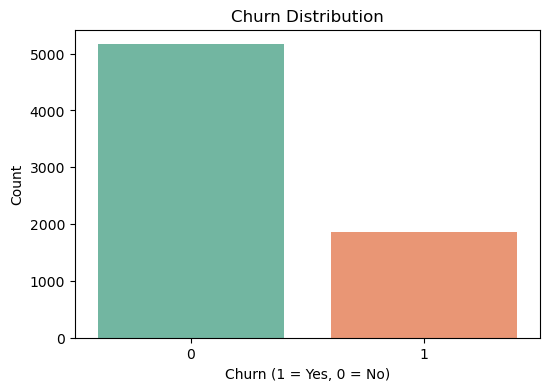

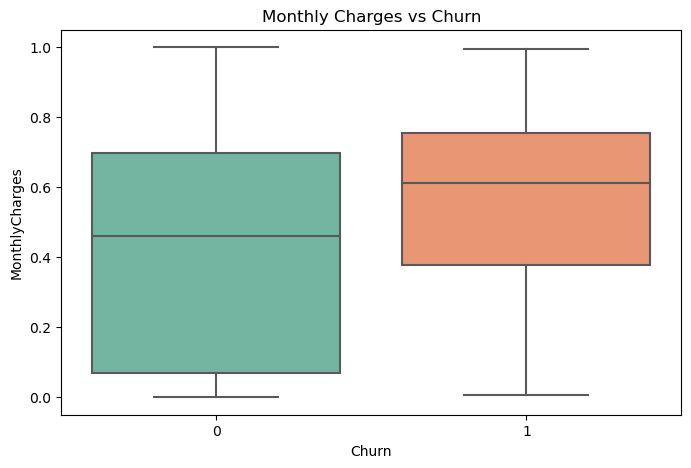

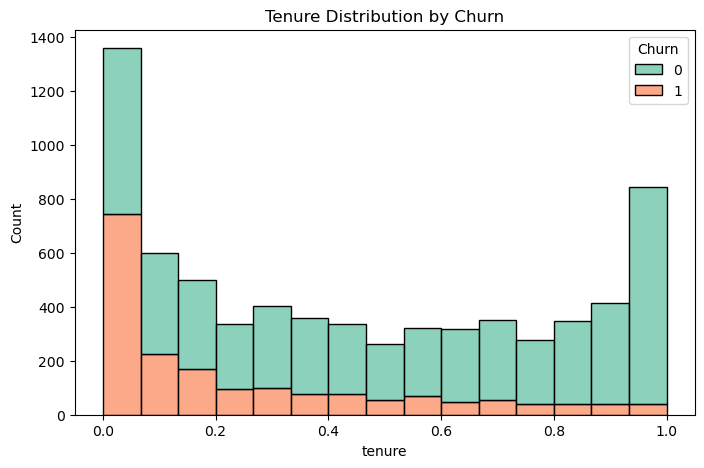

C:\Users\dayaw\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7437 - loss: 0.5161 - val_accuracy: 0.7768 - val_loss: 0.4445
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8015 - loss: 0.4194 - val_accuracy: 0.7868 - val_loss: 0.4405
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8029 - loss: 0.4099 - val_accuracy: 0.7889 - val_loss: 0.4390
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8081 - loss: 0.4131 - val_accuracy: 0.7882 - val_loss: 0.4376
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8082 - loss: 0.4063 - val_accuracy: 0.7861 - val_loss: 0.4384
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8102 - loss: 0.4064 - val_accuracy: 0.7868 - val_loss: 0.4412
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8057 - loss: 0.3996 - val_accuracy: 0.7790 - val_loss: 0.4436
Epoch 8/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8157 - loss: 0.4005 - val_accuracy: 0.

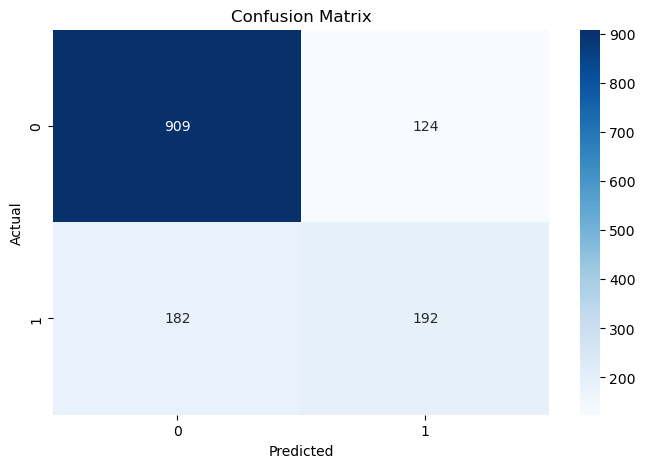

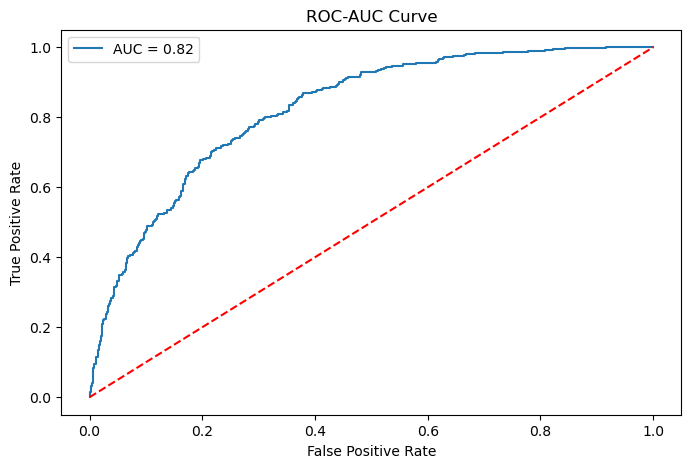

Enter customer details for prediction:
Enter Tenure (in months): 5
Enter Monthly Charges ($): 250
Enter Contract Type (Month-to-Month/One year/Two year): Month-to-Month
Internet Service (DSL/Fiber optic/No): DSL
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

Prediction: Yes
Churn Probability: 0.52

Churn Risk Detected! Recommended Retention Strategies:
- Offer a discount for upgrading to a 1-year or 2-year contract
- Provide special attention to new customers in their first year
- Consider offering a loyalty discount based on current charges


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

def load_data(filepath="customer_churn.csv"):
    df = pd.read_csv(filepath)  # Load the dataset using the correct filename
    df.columns = df.columns.str.strip()  # Remove any leading/trailing spaces from column names
    df.drop('customerID', axis='columns', inplace=True, errors='ignore')  # Drop if it exists
    return df

def clean_data(df):
    df = df[df['TotalCharges'] != ' ']
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
    return df
12

def preprocess_data(df):
    df.replace({'No internet service': 'No', 'No phone service': 'No'}, inplace=True)
    
    yes_no_columns = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
                      'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                      'TechSupport', 'StreamingTV', 'StreamingMovies', 
                      'PaperlessBilling', 'Churn']
    
    missing_cols = [col for col in yes_no_columns if col not in df.columns]
    if missing_cols:
        print(f"Warning: Missing columns in dataset - {missing_cols}")
    
    for col in yes_no_columns:
        if col in df.columns:
            df[col] = df[col].replace({'Yes': 1, 'No': 0})
    
    if 'gender' in df.columns:
        df['gender'] = df['gender'].replace({'Female': 1, 'Male': 0})
    
    categorical_columns = ['InternetService', 'Contract', 'PaymentMethod']
    df = pd.get_dummies(df, columns=[col for col in categorical_columns if col in df.columns], drop_first=True)
    
    return df

def scale_features(df, cols_to_scale):
    scaler = MinMaxScaler()
    df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
    return df, scaler

def build_model(input_shape):
    model = Sequential([
        Dense(64, input_shape=(input_shape,), activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model


def train_model(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32, verbose=1)
    return model

def evaluate_model(model, X_test, y_test):
    y_pred_prob = model.predict(X_test).flatten()
    y_pred = (y_pred_prob > 0.5).astype(int)
    print("\nEvaluation Metrics:")
    print(classification_report(y_test, y_pred))
    print("Accuracy:", accuracy_score(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    plt.figure(figsize=(8, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_pred_prob):.2f}")
    plt.plot([0, 1], [0, 1], 'r--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-AUC Curve')
    plt.legend()
    plt.show()
    
    
def plot_churn_distribution(df):
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x='Churn', palette='Set2')
    plt.title('Churn Distribution')
    plt.xlabel('Churn (1 = Yes, 0 = No)')
    plt.ylabel('Count')
    plt.show()

def plot_insights(df):
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2')
    plt.title('Monthly Charges vs Churn')
    plt.show()
    
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', palette='Set2')
    plt.title('Tenure Distribution by Churn')
    plt.show()


def predict_churn_simple(model, scaler):
    print("Enter customer details for prediction:")
    # Collect only the most important features
    tenure = float(input("Enter Tenure (in months): "))
    monthly_charges = float(input("Enter Monthly Charges ($): "))
    contract_type = input("Enter Contract Type (Month-to-Month/One year/Two year): ").strip()
    internet_service = input("Internet Service (DSL/Fiber optic/No): ").strip()
    
    # Calculate total charges
    total_charges = tenure * monthly_charges
    
    # Set default values for less important features
    # Using common values or middle-ground defaults
    defaults = {
        'gender': 0,  # Male
        'SeniorCitizen': 0,  # No
        'Partner': 0,  # No
        'Dependents': 0,  # No
        'PhoneService': 1,  # Yes
        'MultipleLines': 0,  # No
        'OnlineSecurity': 0,  # No
        'OnlineBackup': 0,  # No
        'DeviceProtection': 0,  # No
        'TechSupport': 0,  # No
        'StreamingTV': 0,  # No
        'StreamingMovies': 0,  # No
        'PaperlessBilling': 1,  # Yes
        'PaymentMethod_Credit card (automatic)': 0,
        'PaymentMethod_Electronic check': 1,  # Electronic check
        'PaymentMethod_Mailed check': 0
    }
    
    # Create internet service dummies
    internet_fiber = 1 if internet_service == "Fiber optic" else 0
    internet_no = 1 if internet_service == "No" else 0
    
    # Create contract dummies
    contract_one_year = 1 if contract_type == "One year" else 0
    contract_two_year = 1 if contract_type == "Two year" else 0
    
    # Create input DataFrame with all required features
    input_data = pd.DataFrame([{
        'gender': defaults['gender'],
        'SeniorCitizen': defaults['SeniorCitizen'],
        'Partner': defaults['Partner'],
        'Dependents': defaults['Dependents'],
        'tenure': tenure,
        'PhoneService': defaults['PhoneService'],
        'MultipleLines': defaults['MultipleLines'],
        'OnlineSecurity': defaults['OnlineSecurity'],
        'OnlineBackup': defaults['OnlineBackup'],
        'DeviceProtection': defaults['DeviceProtection'],
        'TechSupport': defaults['TechSupport'],
        'StreamingTV': defaults['StreamingTV'],
        'StreamingMovies': defaults['StreamingMovies'],
        'PaperlessBilling': defaults['PaperlessBilling'],
        'MonthlyCharges': monthly_charges,
        'TotalCharges': total_charges,
        'InternetService_Fiber optic': internet_fiber,
        'InternetService_No': internet_no,
        'Contract_One year': contract_one_year,
        'Contract_Two year': contract_two_year,
        'PaymentMethod_Credit card (automatic)': defaults['PaymentMethod_Credit card (automatic)'],
        'PaymentMethod_Electronic check': defaults['PaymentMethod_Electronic check'],
        'PaymentMethod_Mailed check': defaults['PaymentMethod_Mailed check']
    }])
    
    # Scale numerical features
    numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
    input_data[numeric_cols] = scaler.transform(input_data[numeric_cols])
    
    # Make prediction
    prediction_prob = model.predict(input_data).flatten()[0]
    prediction = "Yes" if prediction_prob > 0.5 else "No"
    print(f"\nPrediction: {prediction}")
    print(f"Churn Probability: {prediction_prob:.2f}")
    
    if prediction == "Yes":
        print("\nChurn Risk Detected! Recommended Retention Strategies:")
        if contract_type == "Month-to-Month":
            print("- Offer a discount for upgrading to a 1-year or 2-year contract")
        if internet_service == "Fiber optic":
            print("- Review service quality issues with Fiber optic service")
        if tenure < 12:
            print("- Provide special attention to new customers in their first year")
        print("- Consider offering a loyalty discount based on current charges")








def main():
    df = load_data()
    df = clean_data(df)
    df = preprocess_data(df)
    df, scaler = scale_features(df, ['tenure', 'MonthlyCharges', 'TotalCharges'])
    X, y = df.drop('Churn', axis=1), df['Churn']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    plot_churn_distribution(df)
    plot_insights(df)
    
    model = build_model(X_train.shape[1])
    model = train_model(model, X_train, y_train, X_test, y_test)
    evaluate_model(model, X_test, y_test)
    predict_churn_simple(model, scaler)
    

if __name__ == '__main__':
    main()

